# Exploratory Data Analysis (EDA) of Bridge Optimization Datasets

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the new bridge optimization datasets (`data_22.csv`, `data_23.csv`, `data_24.csv`, and `data_25.csv`) located in the `data/` directory.

### Objectives:
1. Understand the structure, columns, and shapes of the new datasets.
2. Analyze the input feature space (spans, widths, footpath, skew angles, steel & concrete grades).
3. Investigate the feasibility rate (`PASS` vs `FAIL`) across different input parameter combinations.
4. Explore the relationship between design parameters and total bridge weight.
5. Identify the properties of the best (minimum weight) feasible designs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Set matplotlib parameters for clean visualizations
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load and Merge Datasets
We will find all CSV files in the `data` directory and load them. Since they represent different runs, we'll concatenate them into a single dataframe for comparison.

In [2]:
data_dir = r"d:/Projects/bridge-optimization/data"
csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))

dfs = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    df_temp = pd.read_csv(file_path)
    df_temp['source_file'] = filename
    print(f"Loaded {filename}: {df_temp.shape[0]} rows, {df_temp.shape[1]} columns")
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged DataFrame Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded data_22.csv: 93800 rows, 23 columns
Loaded data_23.csv: 397000 rows, 23 columns
Loaded data_24.csv: 115200 rows, 23 columns
Loaded data_25.csv: 91200 rows, 23 columns

Merged DataFrame Shape: 697200 rows, 23 columns


## 2. Basic Dataset Info
Let's check the data types and look for any missing values.

In [3]:
print("--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Types ---
span_m                 float64
carriageway_width_m    float64
footpath                   str
skew_angle_deg           int64
steel_grade                str
concrete_grade             str
index                    int64
round                      str
gen                      int64
n                        int64
spacing_m              float64
t_slab_mm              float64
D_mm                   float64
bf_mm                  float64
tf_mm                  float64
tw_mm                  float64
dw_mm                  float64
steel_kN               float64
deck_kN                float64
total_kN               float64
feasible                 int64
status                     str
source_file                str
dtype: object

--- Missing Values ---
span_m                      0
carriageway_width_m         0
footpath               251400
skew_angle_deg              0
steel_grade                 0
concrete_grade              0
index                       0
round               

## 3. Explore the Input Feature Space
Let's check what input features are varying in this new dataset. The potential constant/input variables are:
* `span_m`
* `carriageway_width_m`
* `footpath`
* `skew_angle_deg`
* `steel_grade`
* `concrete_grade`

In [4]:
input_features = ['span_m', 'carriageway_width_m', 'footpath', 'skew_angle_deg', 'steel_grade', 'concrete_grade']

for col in input_features:
    unique_vals = df[col].unique()
    print(f"Column '{col}': {len(unique_vals)} unique values")
    print(f"  Values: {unique_vals}")
    print(f"  Value Counts:\n{df[col].value_counts(dropna=False)}")
    print("-" * 50)

Column 'span_m': 5 unique values
  Values: [22. 23. 24. 25. 26.]
  Value Counts:
span_m
23.0    347600
24.0    143200
25.0    115200
22.0     86400
26.0      4800
Name: count, dtype: int64
--------------------------------------------------
Column 'carriageway_width_m': 11 unique values
  Values: [ 4.25  6.25  8.25 10.25  5.    5.75  6.5   7.25  8.    8.75  9.5 ]
  Value Counts:
carriageway_width_m
4.25     174200
10.25    102600
6.25      72000
8.25      64800
5.00      56800
5.75      37800
6.50      37800
7.25      37800
8.00      37800
8.75      37800
9.50      37800
Name: count, dtype: int64
--------------------------------------------------
Column 'footpath': 3 unique values
  Values: <StringArray>
[nan, 'Single Side', 'Both Sides']
Length: 3, dtype: str
  Value Counts:
footpath
NaN            251400
Single Side    226200
Both Sides     219600
Name: count, dtype: int64
--------------------------------------------------
Column 'skew_angle_deg': 7 unique values
  Values: [-15  -5   

## 4. Feasibility Analysis
Let's check how many designs are feasible (`PASS`) and how the feasibility rate varies across different inputs.

--- Status counts ---
status
FAIL    532169
PASS    165031
Name: count, dtype: int64
status
FAIL    0.763295
PASS    0.236705
Name: proportion, dtype: float64


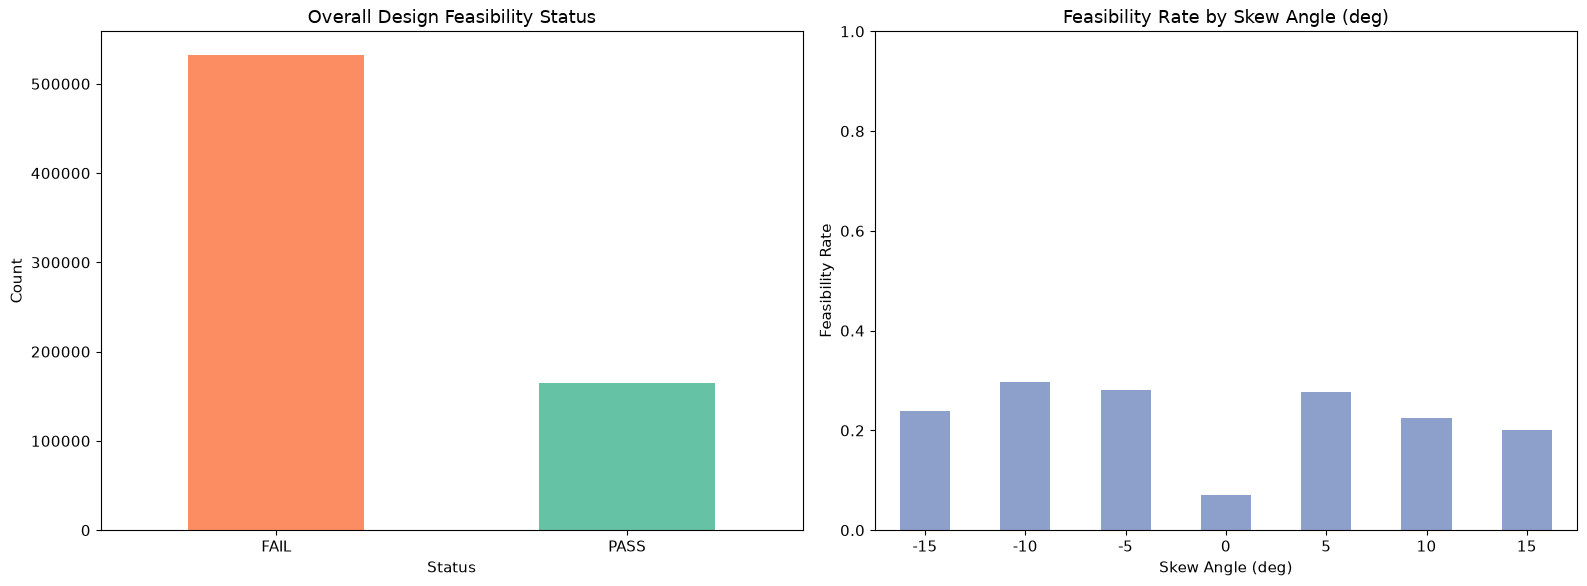

In [5]:
# Overall Feasibility
status_counts = df['status'].value_counts()
status_pct = df['status'].value_counts(normalize=True)
print("--- Status counts ---")
print(status_counts)
print(status_pct)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_counts.plot(kind='bar', ax=axes[0], color=['#fc8d62', '#66c2a5'])
axes[0].set_title("Overall Design Feasibility Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Feasibility rate by skew_angle_deg
skew_feas = df.groupby('skew_angle_deg')['feasible'].mean()
skew_feas.plot(kind='bar', ax=axes[1], color='#8da0cb')
axes[1].set_title("Feasibility Rate by Skew Angle (deg)")
axes[1].set_xlabel("Skew Angle (deg)")
axes[1].set_ylabel("Feasibility Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Feasibility by Steel and Concrete Grades

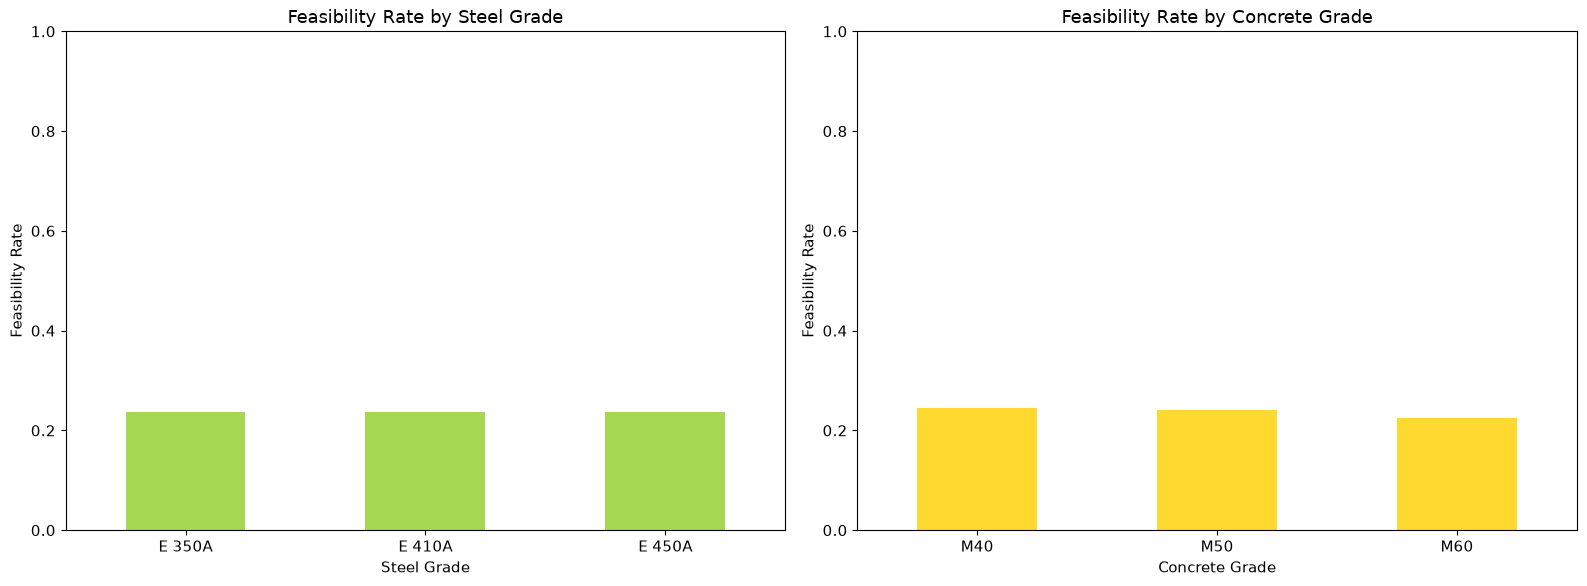

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

steel_feas = df.groupby('steel_grade')['feasible'].mean()
steel_feas.plot(kind='bar', ax=axes[0], color='#a6d854')
axes[0].set_title("Feasibility Rate by Steel Grade")
axes[0].set_xlabel("Steel Grade")
axes[0].set_ylabel("Feasibility Rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

concrete_feas = df.groupby('concrete_grade')['feasible'].mean()
concrete_feas.plot(kind='bar', ax=axes[1], color='#ffd92f')
axes[1].set_title("Feasibility Rate by Concrete Grade")
axes[1].set_xlabel("Concrete Grade")
axes[1].set_ylabel("Feasibility Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Design Parameter Comparison: PASS vs FAIL
How do the girder dimensions and weights differ between designs that PASS and those that FAIL?

In [7]:
design_params = ['n', 'spacing_m', 't_slab_mm', 'D_mm', 'bf_mm', 'tf_mm', 'tw_mm', 'dw_mm', 'total_kN']
grouped = df.groupby('status')[design_params].mean()
print("--- Average Parameter Values by Status ---")
print(grouped.T)

--- Average Parameter Values by Status ---
status            FAIL         PASS
n             3.537173     3.488835
spacing_m     2.942940     2.612637
t_slab_mm   202.987284   188.836037
D_mm       1166.619514  1356.925366
bf_mm       361.024966   414.547358
tf_mm        46.945106    70.352600
tw_mm        22.931167    27.792197
dw_mm      1072.729302  1216.220165
total_kN   1529.491779  1542.590141


### Boxplots of Key Parameters by Status

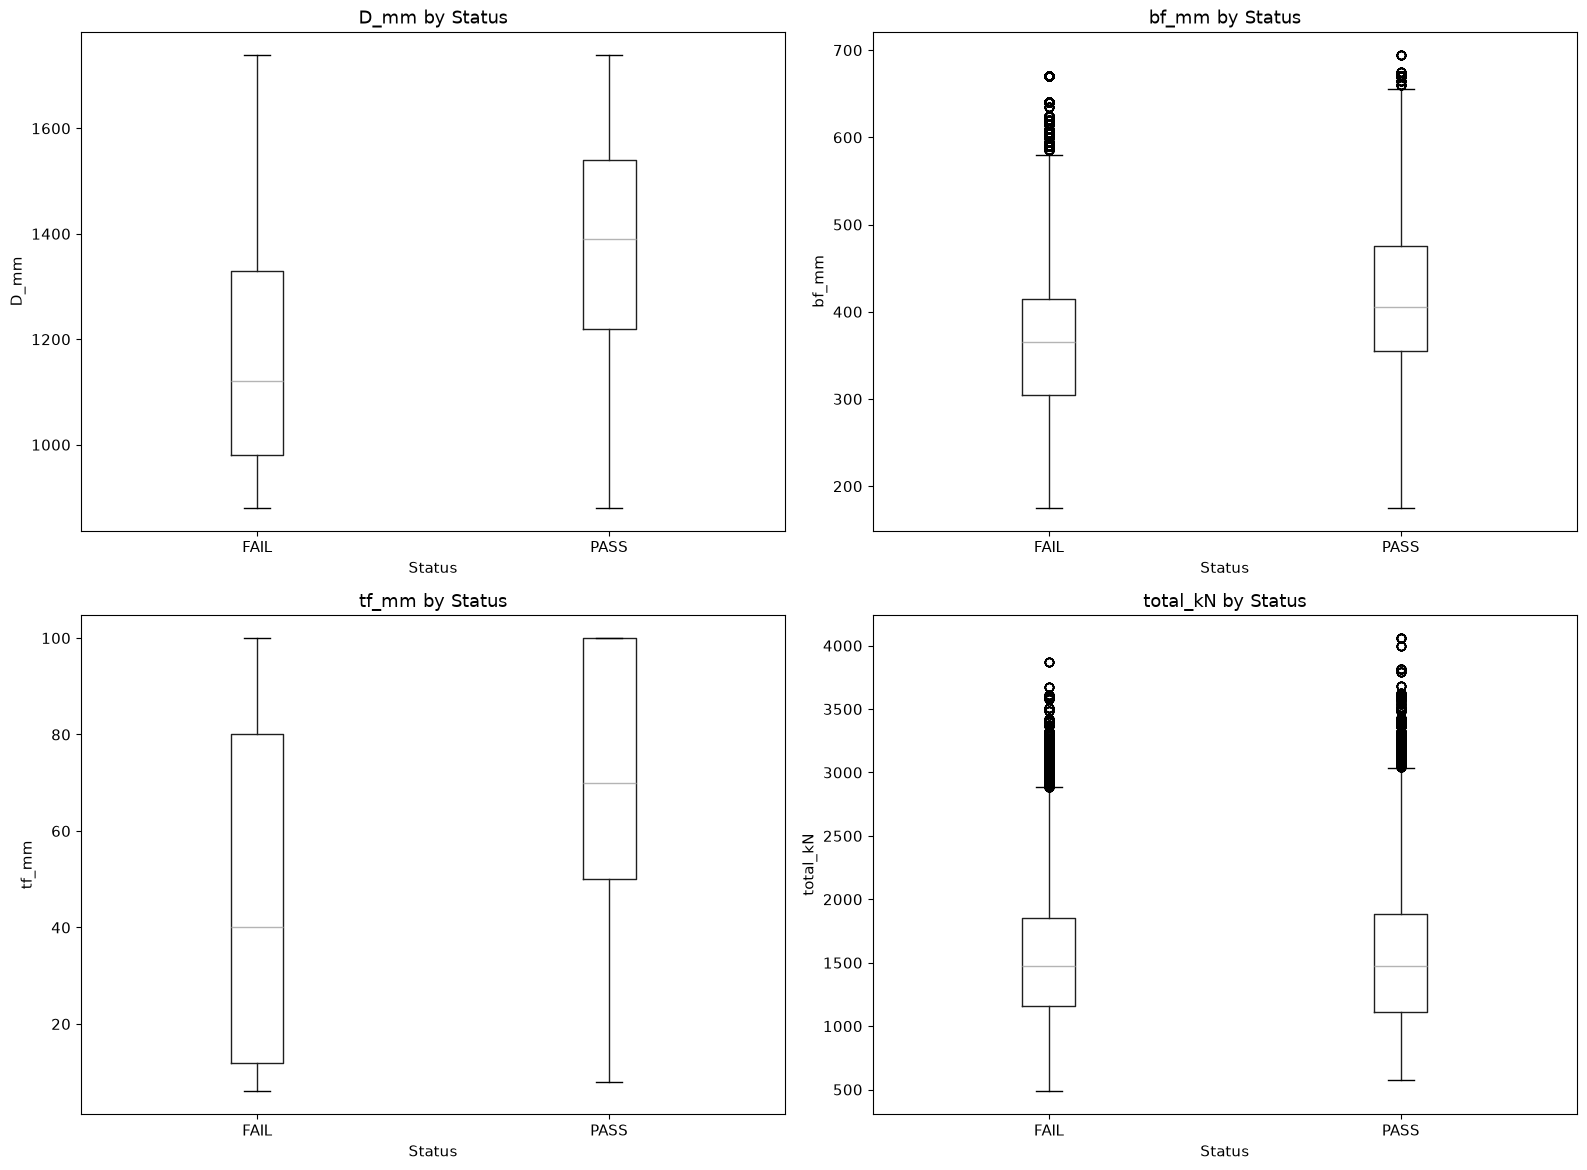

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

plot_cols = ['D_mm', 'bf_mm', 'tf_mm', 'total_kN']
for idx, col in enumerate(plot_cols):
    df.boxplot(column=col, by='status', ax=axes[idx], grid=False)
    axes[idx].set_title(f"{col} by Status")
    axes[idx].set_xlabel("Status")
    axes[idx].set_ylabel(col)

plt.suptitle("") # remove pandas default suptitle
plt.tight_layout()
plt.show()

## 6. Correlation Analysis
Let's see how parameters correlate with each other for feasible (PASS) designs.

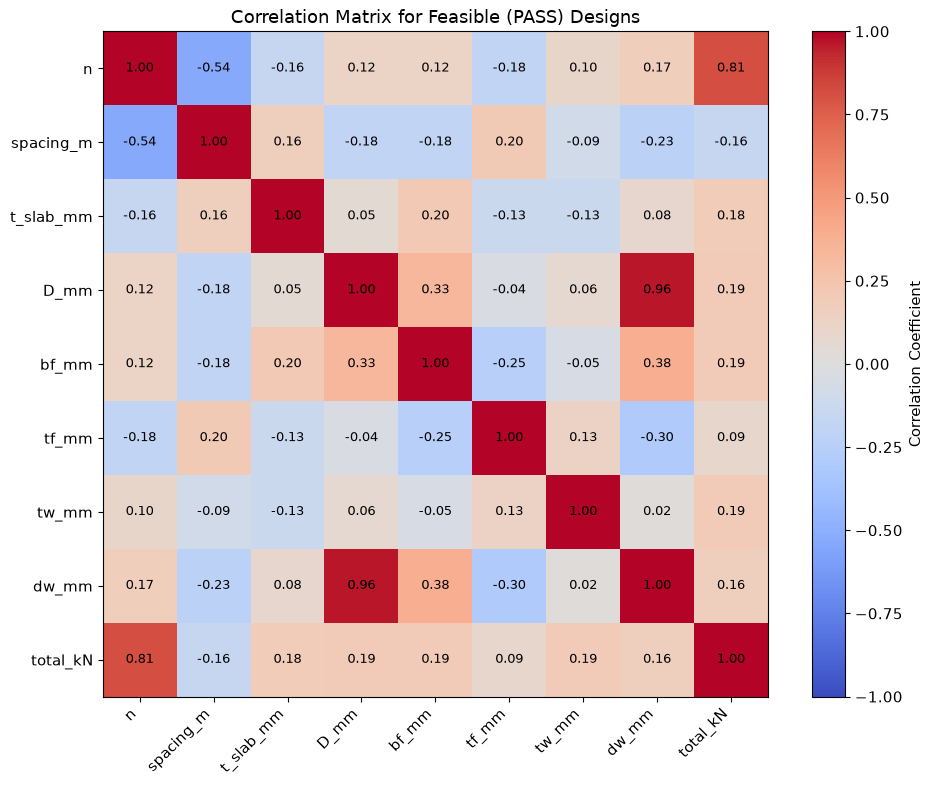

In [9]:
pass_df = df[df['status'] == 'PASS']
corr = pass_df[design_params].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(np.arange(len(design_params)), design_params, rotation=45, ha='right')
plt.yticks(np.arange(len(design_params)), design_params)
plt.title("Correlation Matrix for Feasible (PASS) Designs")

for i in range(len(design_params)):
    for j in range(len(design_params)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Optimization Progress
Let's check how the average weight and feasibility rates change across generations (`gen`) for each of the span lengths.

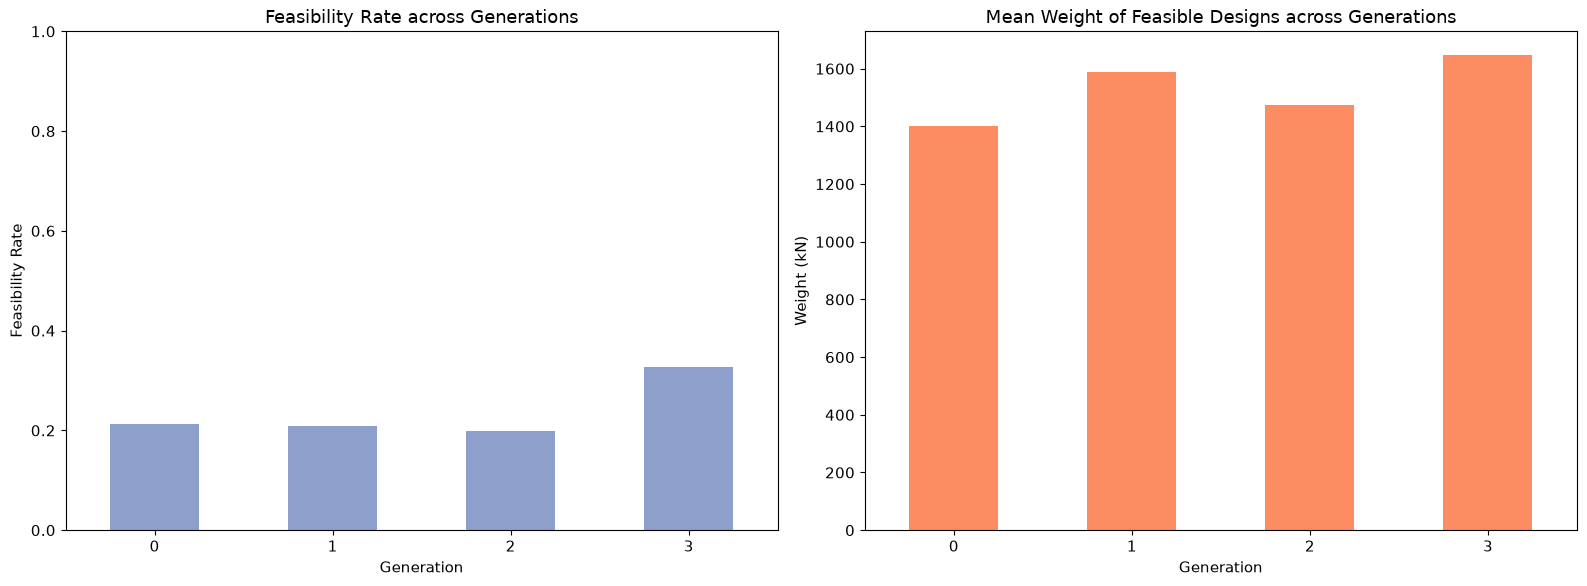

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feasibility rate across generations
gen_feas = df.groupby('gen')['feasible'].mean()
gen_feas.plot(kind='bar', ax=axes[0], color='#8da0cb')
axes[0].set_title("Feasibility Rate across Generations")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Feasibility Rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

# Mean weight of feasible designs across generations
pass_df.groupby('gen')['total_kN'].mean().plot(kind='bar', ax=axes[1], color='#fc8d62')
axes[1].set_title("Mean Weight of Feasible Designs across Generations")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Weight (kN)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Identifying Best Feasible Designs
Let's extract the optimal (lightest weight, feasible) designs for different inputs. Since we have multiple inputs (spans, skew angles, steel and concrete grades), we'll group by them and find the minimum weight design.

In [11]:
group_cols = ['span_m', 'skew_angle_deg', 'steel_grade', 'concrete_grade']
best_idx = pass_df.groupby(group_cols)['total_kN'].idxmin()
best_designs = pass_df.loc[best_idx].copy().reset_index(drop=True)

# Select key columns to show
display_cols = group_cols + ['n', 'spacing_m', 't_slab_mm', 'D_mm', 'bf_mm', 'tf_mm', 'tw_mm', 'steel_kN', 'deck_kN', 'total_kN']
pd.set_option('display.max_rows', 100)
print(f"Found {best_designs.shape[0]} unique optimal design combinations.")
print("\nSample of Best Designs:")
print(best_designs[display_cols].head(30).to_string(index=False))

# Save the optimal designs to a csv for machine learning
best_designs_path = r"d:/Projects/bridge-optimization/data/optimal_designs.csv"
best_designs.to_csv(best_designs_path, index=False)
print(f"\nSaved optimal designs to {best_designs_path}")

Found 222 unique optimal design combinations.

Sample of Best Designs:
 span_m  skew_angle_deg steel_grade concrete_grade  n  spacing_m  t_slab_mm   D_mm  bf_mm  tf_mm  tw_mm  steel_kN  deck_kN  total_kN
   22.0             -15      E 350A            M40  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.9
   22.0             -15      E 350A            M50  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.9
   22.0             -15      E 350A            M60  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.9
   22.0             -15      E 410A            M40  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.9
   22.0             -15      E 410A            M50  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.9
   22.0             -15      E 410A            M60  2      2.575      150.0 1150.0  230.0  100.0   22.0     231.1    424.9     655.